In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [12]:
# 1. LOAD & PREPARE DATA
# ──────────────────────────────────────────────
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Normalize pixel values to [0, 1]
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32)  / 255.0

# Flatten labels
y_train = y_train.flatten()
y_test  = y_test.flatten()

# ⚠️ Use a small subset for speed (NumPy CNN is slow without GPU)
# Increase these numbers if you have time/patience
TRAIN_SIZE = 10000
TEST_SIZE  = 200

x_train, y_train = x_train[:TRAIN_SIZE], y_train[:TRAIN_SIZE]
x_test,  y_test  = x_test[:TEST_SIZE],   y_test[:TEST_SIZE]

print(f"Training samples : {x_train.shape[0]}")
print(f"Testing  samples : {x_test.shape[0]}")
print(f"Image shape      : {x_train.shape[1:]}")


Loading CIFAR-10 dataset...
Training samples : 10000
Testing  samples : 200
Image shape      : (32, 32, 3)


In [3]:
# 2. HELPER FUNCTIONS
# ──────────────────────────────────────────────

def one_hot(labels, num_classes=10):
    """Convert integer labels to one-hot vectors."""
    oh = np.zeros((len(labels), num_classes))
    oh[np.arange(len(labels)), labels] = 1
    return oh

def relu(x):
    return np.maximum(0, x)

def relu_backward(dout, x):
    return dout * (x > 0)

def softmax(x):
    # Subtract max for numerical stability
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def cross_entropy_loss(probs, labels_oh):
    """Compute mean cross-entropy loss."""
    eps = 1e-9
    return -np.mean(np.sum(labels_oh * np.log(probs + eps), axis=1))


In [4]:
# 3. CONVOLUTIONAL LAYER
# ──────────────────────────────────────────────

class ConvLayer:
    """
    Single convolutional layer.
    Params:
        num_filters : number of output feature maps
        filter_size : height = width of each filter (e.g. 3 → 3x3)
        stride      : step size (default 1)
        padding     : 'same' keeps spatial size, 'valid' shrinks it
    """
    def __init__(self, num_filters, filter_size, stride=1, padding='same'):
        self.num_filters = num_filters
        self.filter_size = filter_size
        self.stride      = stride
        self.padding     = padding
        self.W = None    # will be initialised on first forward pass
        self.b = None

    def _init_weights(self, in_channels):
        f = self.filter_size
        # He initialisation
        scale = np.sqrt(2.0 / (f * f * in_channels))
        self.W = np.random.randn(self.num_filters, in_channels, f, f) * scale
        self.b = np.zeros((self.num_filters, 1))

    def _pad(self, x):
        if self.padding == 'same':
            p = self.filter_size // 2
            return np.pad(x, ((0,0),(0,0),(p,p),(p,p)), mode='constant')
        return x   # 'valid' — no padding

    def forward(self, x):
        """
        x shape: (N, C, H, W)
        returns: (N, num_filters, H_out, W_out)
        """
        N, C, H, W = x.shape
        if self.W is None:
            self._init_weights(C)

        x_pad  = self._pad(x)
        f      = self.filter_size
        H_out  = (x_pad.shape[2] - f) // self.stride + 1
        W_out  = (x_pad.shape[3] - f) // self.stride + 1

        out = np.zeros((N, self.num_filters, H_out, W_out))

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * self.stride
                w_start = j * self.stride
                patch = x_pad[:, :, h_start:h_start+f, w_start:w_start+f]
                # patch: (N, C, f, f)  →  dot with W: (F, C, f, f)
                out[:, :, i, j] = np.tensordot(patch, self.W,
                                               axes=([1,2,3],[1,2,3])) + self.b.T

        self.x     = x
        self.x_pad = x_pad
        return out

    def backward(self, dout, lr=0.001):
        """
        dout shape: (N, num_filters, H_out, W_out)
        returns: dx with same shape as x
        """
        N, C, H, W = self.x.shape
        f          = self.filter_size
        x_pad      = self.x_pad

        dW     = np.zeros_like(self.W)
        db     = np.zeros_like(self.b)
        dx_pad = np.zeros_like(x_pad)

        _, _, H_out, W_out = dout.shape

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * self.stride
                w_start = j * self.stride
                patch = x_pad[:, :, h_start:h_start+f, w_start:w_start+f]

                # dW: sum over batch
                for n in range(N):
                    dW += dout[n, :, i, j][:, None, None, None] * patch[n][None, :, :, :]

                # dx_pad
                dx_pad[:, :, h_start:h_start+f, w_start:w_start+f] += \
                    np.tensordot(dout[:, :, i, j], self.W, axes=([1],[0]))

        db = dout.sum(axis=(0,2,3)).reshape(self.b.shape)

        # Update weights
        self.W -= lr * dW / N
        self.b -= lr * db / N

        # Remove padding from dx
        if self.padding == 'same':
            p  = f // 2
            dx = dx_pad[:, :, p:-p, p:-p]
        else:
            dx = dx_pad

        return dx

In [5]:
# 4. MAX POOLING LAYER
# ──────────────────────────────────────────────

class MaxPoolLayer:
    """2×2 max pooling with stride 2."""
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride    = stride

    def forward(self, x):
        N, C, H, W = x.shape
        p = self.pool_size
        s = self.stride
        H_out = (H - p) // s + 1
        W_out = (W - p) // s + 1

        out  = np.zeros((N, C, H_out, W_out))
        self.x = x

        for i in range(H_out):
            for j in range(W_out):
                patch = x[:, :, i*s:i*s+p, j*s:j*s+p]
                out[:, :, i, j] = np.max(patch, axis=(2, 3))

        return out

    def backward(self, dout):
        x = self.x
        N, C, H, W = x.shape
        p = self.pool_size
        s = self.stride
        H_out, W_out = dout.shape[2], dout.shape[3]

        dx = np.zeros_like(x)

        for i in range(H_out):
            for j in range(W_out):
                patch = x[:, :, i*s:i*s+p, j*s:j*s+p]
                max_val = np.max(patch, axis=(2,3), keepdims=True)
                mask    = (patch == max_val)
                dx[:, :, i*s:i*s+p, j*s:j*s+p] += \
                    mask * dout[:, :, i, j][:, :, None, None]

        return dx

In [6]:
# 5. FULLY CONNECTED (DENSE) LAYER
# ──────────────────────────────────────────────

class DenseLayer:
    def __init__(self, input_size, output_size):
        scale    = np.sqrt(2.0 / input_size)
        self.W   = np.random.randn(input_size, output_size) * scale
        self.b   = np.zeros((1, output_size))

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout, lr=0.001):
        N   = self.x.shape[0]
        dW  = self.x.T @ dout / N
        db  = dout.sum(axis=0, keepdims=True) / N
        dx  = dout @ self.W.T
        self.W -= lr * dW
        self.b -= lr * db
        return dx

In [7]:
# 6. FULL CNN MODEL
# ──────────────────────────────────────────────

class CNNFromScratch:
    """
    Architecture:
    Input (N,3,32,32)
      → Conv(8, 3x3) → ReLU → MaxPool(2x2)   → (N,8,16,16)
      → Conv(16, 3x3) → ReLU → MaxPool(2x2)  → (N,16,8,8)
      → Flatten                               → (N,1024)
      → Dense(128) → ReLU
      → Dense(10)  → Softmax
    """
    def __init__(self, lr=0.001):
        self.lr     = lr
        self.conv1  = ConvLayer(num_filters=8,  filter_size=3, padding='same')
        self.pool1  = MaxPoolLayer()
        self.conv2  = ConvLayer(num_filters=16, filter_size=3, padding='same')
        self.pool2  = MaxPoolLayer()
        self.dense1 = DenseLayer(16 * 8 * 8, 128)
        self.dense2 = DenseLayer(128, 10)

        # cache for backward
        self.c1_out = self.c2_out = None

    def forward(self, x):
        # x: (N, 3, 32, 32)
        out = self.conv1.forward(x)           # (N, 8, 32, 32)
        self.c1_out = out.copy()
        out = relu(out)
        out = self.pool1.forward(out)         # (N, 8, 16, 16)

        out = self.conv2.forward(out)         # (N, 16, 16, 16)
        self.c2_out = out.copy()
        out = relu(out)
        out = self.pool2.forward(out)         # (N, 16, 8, 8)

        N       = out.shape[0]
        out     = out.reshape(N, -1)          # Flatten → (N, 1024)

        out     = self.dense1.forward(out)    # (N, 128)
        self.d1_out = out.copy()
        out     = relu(out)

        out     = self.dense2.forward(out)    # (N, 10)
        probs   = softmax(out)
        return probs

    def backward(self, probs, labels_oh):
        lr = self.lr

        # --- Softmax + Cross-entropy gradient ---
        d = (probs - labels_oh) / probs.shape[0]   # (N, 10)

        # Dense 2
        d = self.dense2.backward(d, lr)             # (N, 128)

        # ReLU after dense1
        d = relu_backward(d, self.d1_out)

        # Dense 1
        d = self.dense1.backward(d, lr)             # (N, 1024)

        # Reshape back to conv shape (N, 16, 8, 8)
        d = d.reshape(-1, 16, 8, 8)

        # Pool2 backward
        d = self.pool2.backward(d)                  # (N, 16, 16, 16)

        # ReLU after conv2
        d = relu_backward(d, self.c2_out)

        # Conv2 backward
        d = self.conv2.backward(d, lr)              # (N, 8, 16, 16)

        # Pool1 backward
        d = self.pool1.backward(d)                  # (N, 8, 32, 32)

        # ReLU after conv1
        d = relu_backward(d, self.c1_out)

        # Conv1 backward
        self.conv1.backward(d, lr)

    def predict(self, x):
        probs = self.forward(x)
        return np.argmax(probs, axis=1)

    def accuracy(self, x, y, batch_size=50):
        correct = 0
        for i in range(0, len(x), batch_size):
            xb = x[i:i+batch_size].transpose(0,3,1,2)
            yb = y[i:i+batch_size]
            preds = self.predict(xb)
            correct += np.sum(preds == yb)
        return correct / len(x)

In [8]:
# 7. TRAINING LOOP
# ──────────────────────────────────────────────

def train(model, x_train, y_train, x_test, y_test,
          epochs=10, batch_size=32):

    train_losses = []
    train_accs   = []
    test_accs    = []

    N = len(x_train)

    for epoch in range(epochs):
        # Shuffle training data each epoch
        idx = np.random.permutation(N)
        x_train, y_train = x_train[idx], y_train[idx]

        epoch_loss = 0
        num_batches = 0

        for i in range(0, N, batch_size):
            xb = x_train[i:i+batch_size]
            yb = y_train[i:i+batch_size]

            # CIFAR images are (N,H,W,C) → convert to (N,C,H,W) for conv
            xb_t = xb.transpose(0, 3, 1, 2)
            yb_oh = one_hot(yb, 10)

            # Forward
            probs = model.forward(xb_t)

            # Loss
            loss = cross_entropy_loss(probs, yb_oh)
            epoch_loss += loss
            num_batches += 1

            # Backward
            model.backward(probs, yb_oh)

        avg_loss = epoch_loss / num_batches
        tr_acc   = model.accuracy(x_train, y_train)
        te_acc   = model.accuracy(x_test,  y_test)

        train_losses.append(avg_loss)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | "
              f"Train Acc: {tr_acc*100:.2f}% | "
              f"Test Acc: {te_acc*100:.2f}%")

    return train_losses, train_accs, test_accs

In [13]:
# 8. RUN
# ──────────────────────────────────────────────
print("\nInitialising CNN from scratch...")
model = CNNFromScratch(lr=0.001)   # was 0.01

losses, tr_accs, te_accs = train(
    model, x_train, y_train, x_test, y_test,
    epochs=20,        # was 10
    batch_size=64     # was 32
)


Initialising CNN from scratch...
Epoch  1/20 | Loss: 2.4664 | Train Acc: 9.43% | Test Acc: 11.00%
Epoch  2/20 | Loss: 2.4514 | Train Acc: 9.54% | Test Acc: 10.50%
Epoch  3/20 | Loss: 2.4389 | Train Acc: 9.60% | Test Acc: 11.00%
Epoch  4/20 | Loss: 2.4290 | Train Acc: 9.70% | Test Acc: 11.00%
Epoch  5/20 | Loss: 2.4189 | Train Acc: 9.82% | Test Acc: 11.00%
Epoch  6/20 | Loss: 2.4094 | Train Acc: 9.94% | Test Acc: 11.00%
Epoch  7/20 | Loss: 2.4033 | Train Acc: 10.04% | Test Acc: 11.00%
Epoch  8/20 | Loss: 2.3955 | Train Acc: 10.00% | Test Acc: 12.00%
Epoch  9/20 | Loss: 2.3881 | Train Acc: 10.19% | Test Acc: 12.00%
Epoch 10/20 | Loss: 2.3826 | Train Acc: 10.13% | Test Acc: 12.50%
Epoch 11/20 | Loss: 2.3765 | Train Acc: 10.25% | Test Acc: 12.00%
Epoch 12/20 | Loss: 2.3715 | Train Acc: 10.24% | Test Acc: 12.00%
Epoch 13/20 | Loss: 2.3677 | Train Acc: 10.33% | Test Acc: 12.50%
Epoch 14/20 | Loss: 2.3625 | Train Acc: 10.33% | Test Acc: 11.50%
Epoch 15/20 | Loss: 2.3593 | Train Acc: 10.38% |

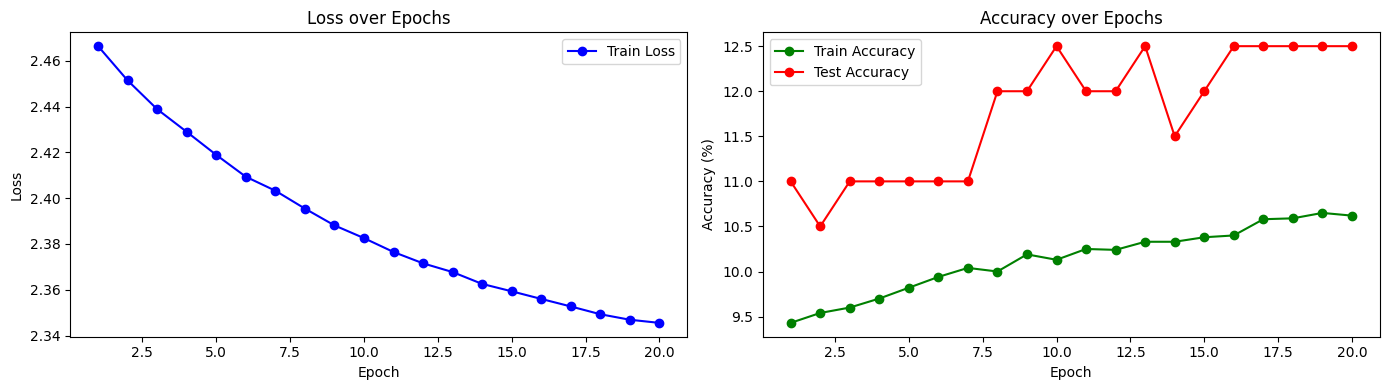


Plot saved as training_results.png


In [14]:
# 9. PLOT RESULTS
# ──────────────────────────────────────────────
epochs_range = range(1, len(losses)+1)

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, losses, 'b-o', label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a*100 for a in tr_accs], 'g-o', label='Train Accuracy')
plt.plot(epochs_range, [a*100 for a in te_accs], 'r-o', label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig("training_results.png")
plt.show()
print("\nPlot saved as training_results.png")


Sample Predictions:


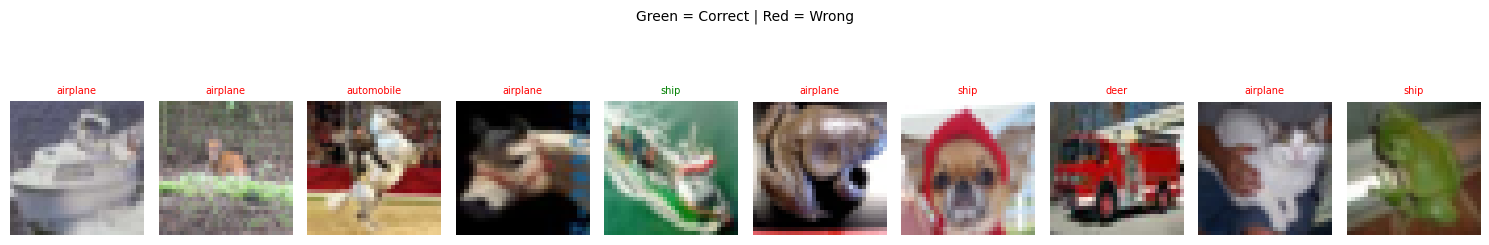

Predictions saved as predictions.png


In [15]:
# 10. VISUALISE PREDICTIONS
# ──────────────────────────────────────────────
print("\nSample Predictions:")
sample_idx = np.random.choice(len(x_test), 10, replace=False)
x_sample   = x_test[sample_idx]
y_sample   = y_test[sample_idx]
y_pred     = model.predict(x_sample.transpose(0,3,1,2))

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_sample[i])
    color = 'green' if y_pred[i] == y_sample[i] else 'red'
    plt.title(CLASS_NAMES[y_pred[i]], color=color, fontsize=7)
    plt.axis('off')
plt.suptitle("Green = Correct | Red = Wrong", fontsize=10)
plt.tight_layout()
plt.savefig("predictions.png")
plt.show()
print("Predictions saved as predictions.png")